Importamos librerías


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


Cargar dataset real


In [3]:
df = pd.read_csv("CC GENERAL.csv")

Quitamos columna de ID (no es útil para clustering)

In [4]:
X = df.drop(columns=["CUST_ID"])

In [5]:
# Rellenamos valores nulos
X = X.fillna(0)

In [6]:
# Revisar si hay valores nulos
print( X.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)   # Esto es como nuestro "X" de make_blobs
y = None  # Aún no hay etiquetas de cluster


In [9]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)


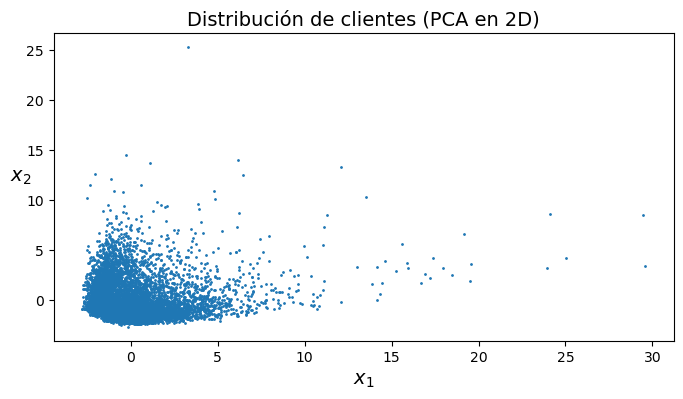

In [10]:
plt.figure(figsize=(8,4))
plot_clusters(X_reduced, y)
plt.title("Distribución de clientes (PCA en 2D)", fontsize=14)
plt.show()



Definir número de clusters

In [11]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_reduced)
print("Etiquetas de cluster para cada cliente:", y_pred)


Etiquetas de cluster para cada cliente: [3 0 1 ... 1 3 3]


In [12]:
# Ver los centroides encontrados
print("Centroides de los clusters:\n", kmeans.cluster_centers_)


Centroides de los clusters:
 [[-0.48057302  3.6767176 ]
 [ 0.32067134 -1.27607996]
 [ 3.46387455 -0.21022807]
 [-1.4597228   0.05444145]
 [12.17661308  2.46220443]]


In [13]:
# Nuevos clientes en el espacio reducido (2D PCA)
X_new = np.array([
    [0, 2],
    [3, 2],
    [-3, 3],
    [-3, 2.5]
])

print("Predicción:", kmeans.predict(X_new))


# Crear un nuevo cliente con 17 valores (ejemplo ficticio)
#X_new = np.array([
   # [0, 2] + [0]*15,
   # [3, 2] + [0]*15,
   # [-3, 3] + [0]*15,
 #   [-3, 2.5] + [0]*15
#])

#print("Predicción (modelo entrenado en 17 features):", kmeans.predict(X_new))



Predicción: [0 2 0 0]


In [14]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)


Visualizar la frontera de decisión

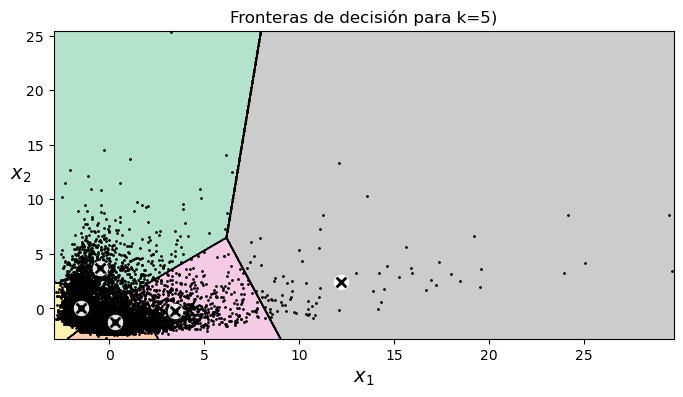

In [15]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X_reduced)  # ahora sí funciona
plt.title("Fronteras de decisión para k=5)")
plt.show()

In [16]:
kmeans.transform(X_new)

array([[ 1.74422829,  3.29173662,  4.1089579 ,  2.43228056, 12.18538219],
       [ 3.86338847,  4.23219824,  2.25838166,  4.86562694,  9.18824579],
       [ 2.60872747,  5.41402974,  7.21714891,  3.32396886, 15.18613871],
       [ 2.78067917,  5.02848268,  7.0090663 ,  2.89019211, 15.17666015]])

In [17]:
kmeans_iter1 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=5)

# 👇 entrenar con X_reduced, NO con X
kmeans_iter1.fit(X_reduced)
kmeans_iter2.fit(X_reduced)
kmeans_iter3.fit(X_reduced)


,n_clusters,5
,init,'k-means++'
,n_init,1
,max_iter,3
,tol,0.0001
,verbose,0
,random_state,5
,copy_x,True
,algorithm,'elkan'


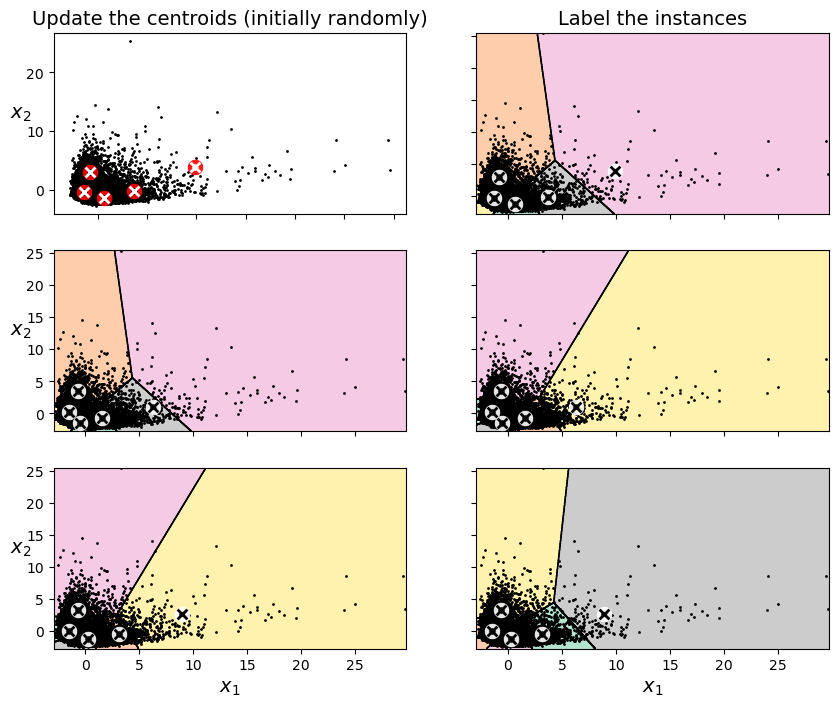

In [18]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X_reduced)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X_reduced, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X_reduced, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X_reduced, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X_reduced, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X_reduced, show_ylabels=False)

plt.show()

In [19]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

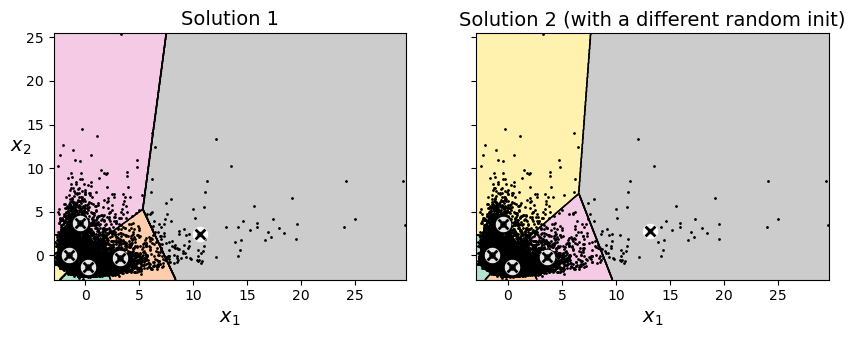

In [20]:
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X_reduced,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

In [21]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X_reduced)

,n_clusters,5
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,11
,copy_x,True
,algorithm,'elkan'


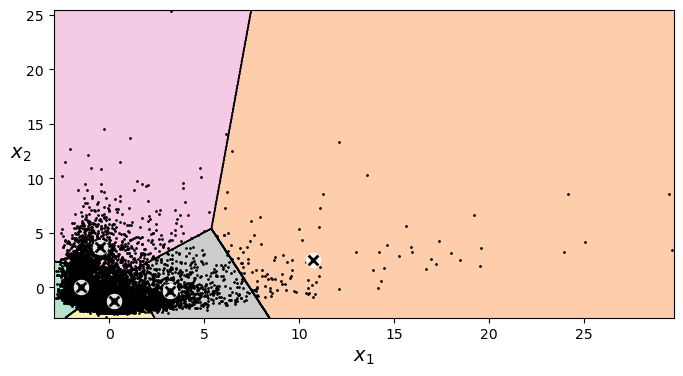

In [22]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X_reduced)
plt.show()

In [23]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np

# Dataset escalado (17 features)
X_data = X_scaled   # 👈 así usamos tu dataset real en lugar de MNIST


In [24]:
def load_next_batch(batch_size):
    return X_data[np.random.choice(len(X_data), batch_size, replace=False)]


In [25]:
k = 5                  # número de clusters
n_init = 10            # repeticiones con distintas inicializaciones
n_iterations = 100     # iteraciones del minibatch
batch_size = 1024      # tamaño del lote
init_size = 500        # tamaño inicial para centrar clusters
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size, random_state=init)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans


In [26]:
# Evaluación del mejor modelo
print("Inercia acumulada (menor es mejor):", best_kmeans.sum_inertia_)
print("Score del mejor modelo:", best_kmeans.score(X_data))
print("Centroides encontrados:\n", best_kmeans.cluster_centers_)

Inercia acumulada (menor es mejor): 99401.68042128511
Score del mejor modelo: -92862.8779129365
Centroides encontrados:
 [[ 1.53184067e+00  3.74440122e-01 -1.86201409e-01 -1.28088829e-01
  -2.05039663e-01  1.78926516e+00 -3.72557688e-01 -1.37994415e-01
  -3.41188678e-01  1.76360394e+00  1.67926010e+00 -2.15781491e-01
   9.35166622e-01  6.81433017e-01  5.24057154e-01 -3.95556884e-01
  -8.15520180e-02]
 [-6.09744435e-01 -1.45645744e+00 -2.29660271e-01 -1.30828319e-01
  -3.02404714e-01 -3.46873333e-01 -3.49980816e-01 -1.35120986e-01
  -4.51679556e-01 -5.06128872e-01 -3.84674853e-01 -3.46131345e-01
  -1.84135228e-01 -2.23994994e-01 -2.70439738e-01  1.89471459e-01
  -1.25735095e-01]
 [-3.11295831e-01  3.80305176e-01  1.19187823e-01 -1.64246326e-02
   3.11709341e-01 -3.65842736e-01  1.03921462e+00  2.71415206e-01
   9.93755956e-01 -4.60467120e-01 -3.60108207e-01  3.40518445e-01
  -9.50649875e-02 -1.38592873e-01 -6.36374423e-02  3.69641775e-01
   6.70513568e-02]
 [ 8.73174042e-01  4.61980943e

In [27]:
best_kmeans.score(X_scaled)

-92862.8779129365

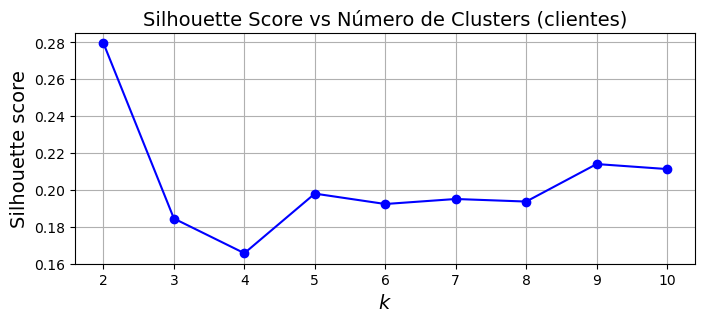

In [28]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Evaluamos distintos valores de k en tus datos escalados
max_k = 10  # puedes subirlo si quieres explorar más
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X_scaled) for k in range(2, max_k + 1)]
silhouette_scores = [silhouette_score(X_scaled, model.labels_) for model in kmeans_per_k]

# Graficamos
ks = list(range(2, max_k + 1))
plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters (clientes)", fontsize=14)
plt.grid(True)
plt.show()


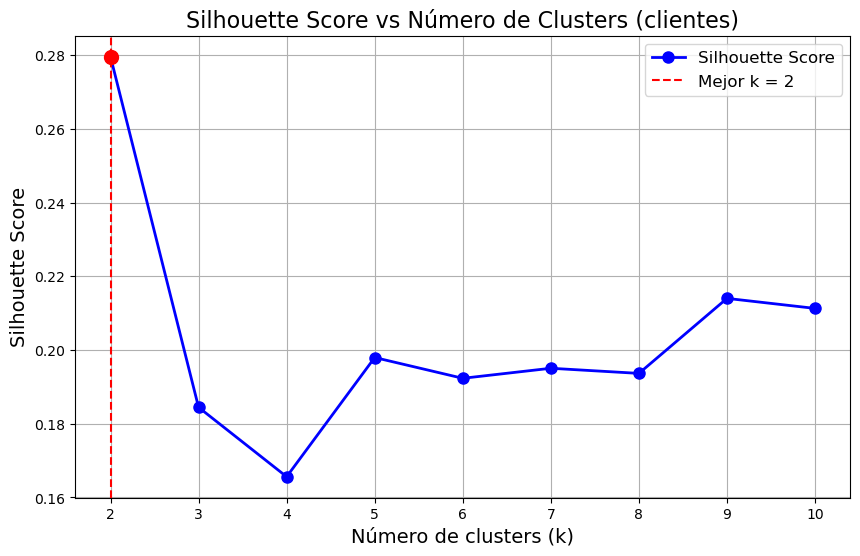

In [29]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.plot(ks, silhouette_scores, "bo-", linewidth=2, markersize=8, label="Silhouette Score")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters (clientes)", fontsize=16)
plt.grid(True)

# Resaltar el mejor k
best_k = ks[np.argmax(silhouette_scores)]
best_score = np.max(silhouette_scores)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Mejor k = {best_k}")
plt.scatter(best_k, best_score, color="red", s=100, zorder=5)

plt.legend(fontsize=12)
plt.show()


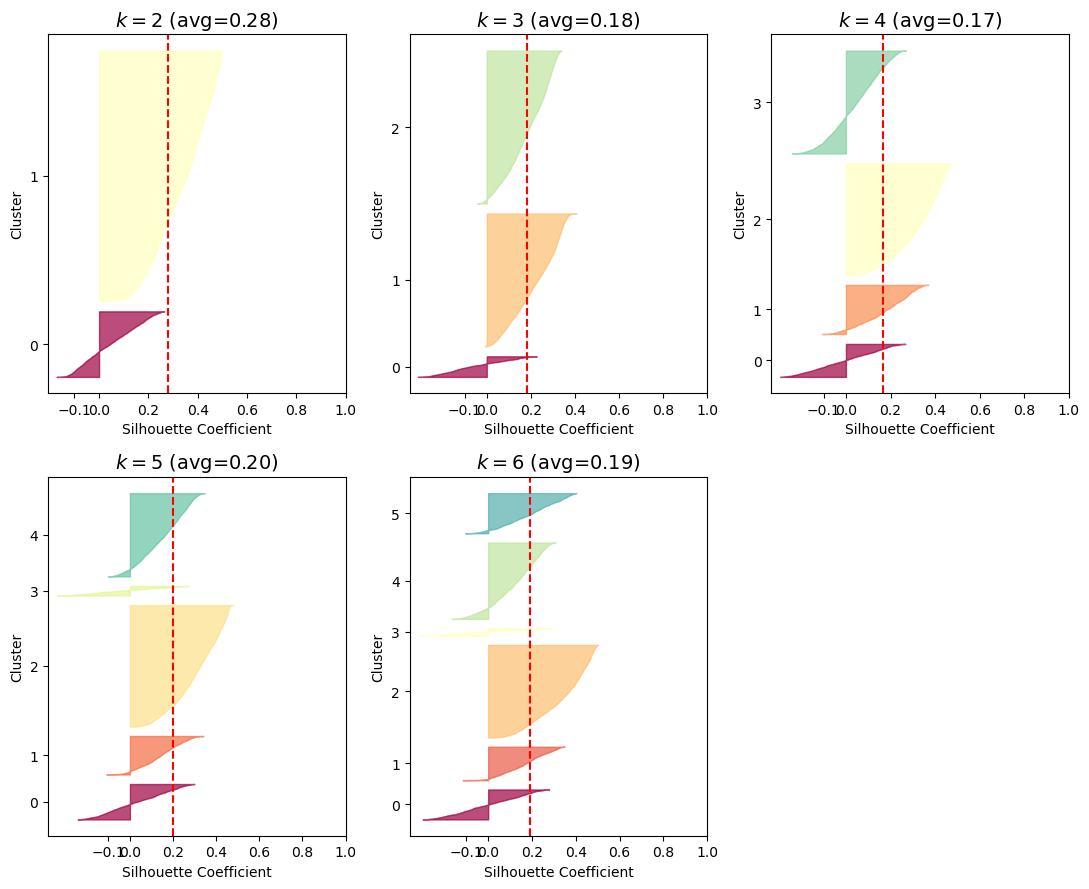

In [30]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# Definir los valores de k que quieres analizar
valid_ks = [k for k in (2, 3, 4, 5, 6) if k <= len(kmeans_per_k)]  

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 3, plot_idx + 1)  # (2 filas, 3 columnas) y posición dinámica

    # Entrenar modelo para este k
    model = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    y_pred = model.labels_

    # Calcular coeficientes silhouette individuales
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred)

    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    # Línea roja en el promedio silhouette
    avg_score = silhouette_score(X_scaled, y_pred)
    plt.axvline(x=avg_score, color="red", linestyle="--")
    plt.title(f"$k={k}$ (avg={avg_score:.2f})", fontsize=14)

plt.tight_layout()
plt.show()


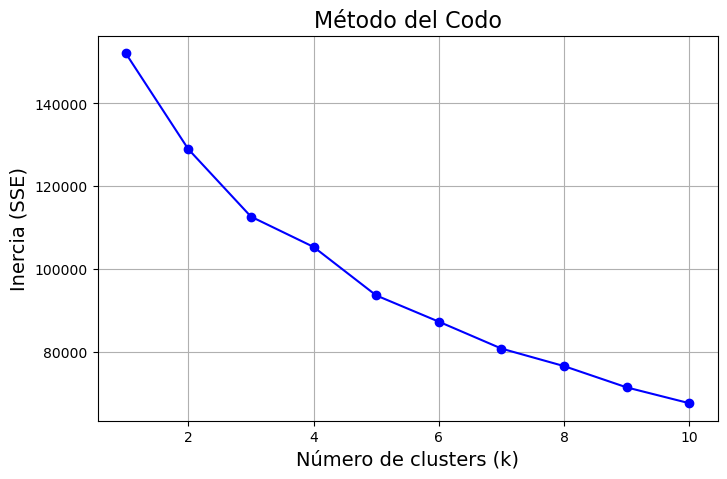

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 11)  # probamos de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia (SSE)", fontsize=14)
plt.title("Método del Codo", fontsize=16)
plt.grid(True)
plt.show()




### 🔸 Objetivos principales:

1. **Segmentar clientes (Clustering):**

   * Encontrar grupos de clientes con comportamientos similares.
   * Ejemplo:
     * Clientes que pagan siempre y casi no tienen deudas.
     * Clientes que usan la tarjeta para adelantos de efectivo.
     * Clientes que gastan mucho pero no pagan a tiempo.
     * Clientes de bajo uso (casi no mueven la tarjeta).

### 🔸 En el caso de tu dataset (Credit Card Dataset for Clustering):

Lo que **buscamos específicamente** es:
 **Agrupar clientes en clusters** para descubrir perfiles financieros ocultos.
 **Analizar características por cluster** (ejemplo: promedio de compras, pagos, adelantos, balances).
 **Visualizar esos grupos** con PCA para interpretarlos mejor.

 En otras palabras:

* **No queremos predecir una variable “y”.**
* Queremos **descubrir estructura y segmentación dentro de los datos**.

---

 Ejemplo de hallazgo:

* Cluster 0 → “Clientes conservadores” (pocas compras, bajo balance).
* Cluster 1 → “Clientes endeudados” (alto balance, bajo pago).
* Cluster 2 → “Grandes compradores” (gastos altos y pagos altos).
* Cluster 3 → “Clientes inactivos” (casi no usan la tarjeta).

---


